# Measure the galaxy bias of your galaxy sample 

In the previous notebook you measured the angular correlation function of your own DMASS sample. 
In this notebook, we will infer the galaxy bias of your DMASS galaxy sample and compare yours with that of CMASS. 

Galaxies don't trace the dark matter distribution perfectly, they form preferentially in the densest regions, so their clustering is amplified relative to the underlying matter. This amplification is captured by the linear galaxy bias, b: on large scales, the galaxy correlation function is related to the matter correlation function simply by

$$ w_{\rm galaxy} (\theta) = b^2 \times w_{\rm matter}(\theta) $$

A bias of b ~ 2 (typical for CMASS-like galaxies) means these galaxies cluster about twice as strongly as the dark matter itself. In this notebook, we'll use the measured $w(\theta)$ for CMASS and your DMASS sample, together with the theoretical matter $w(\theta)$ provided, to solve for the value of b that best matches each dataset.

In [9]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import fitsio
import treecorr

# Make plots look nicer
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 13


%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Matter theoretical correlation function
matter_theory_file = np.genfromtxt('/fs/ess/PHS0411/summer/correlation_function/matter_correlation_function_theory.txt', names=True, skip_header=0)
theta_matter_theory = matter_theory_file['thetaarcmin']
wtheta_matter_theory = matter_theory_file['wtheta']

# CMASS theoretical correlation function
b_cmass_theory = 2 
wtheta_cmass_theory = b_cmass_theory**2 * wtheta_matter_theory

In [ ]:
# call cmass correlation function
result_cmass = np.genfromtxt('/fs/ess/PHS0411/summer/correlation_function/wtheta_cmass_jk100.txt', names=True, skip_header=1)
cov_cmass = np.genfromtxt('/fs/ess/PHS0411/summer/correlation_function/cov_cmass_jk100.txt')

theta_cmass = result_cmass['meanr']
wtheta_cmass = result_cmass['xi']
err_wtheta_cmass = result_cmass['sigma_xi']

In [27]:
# load your saved result
result_dmass = np.genfromtxt('../output/correlation_function/wtheta_dmass_jk30_ra330_360.txt', names=True, skip_header=1)
cov_dmass = cov_cmass * 2525/150
theta_dmass = result_dmass['meanr']
wtheta_dmass = result_dmass['xi']
err_wtheta_dmass = result_dmass['sigma_xi']

The dashed blue curve (b=2 times matter theory) tracks the CMASS measurements closely, this confirms that b ~ 2 is a reasonable bias for CMASS-like galaxies, and sets up the fit we're about to do more rigorously below.

Text(0, 0.5, '$\\theta w(\\theta)$')

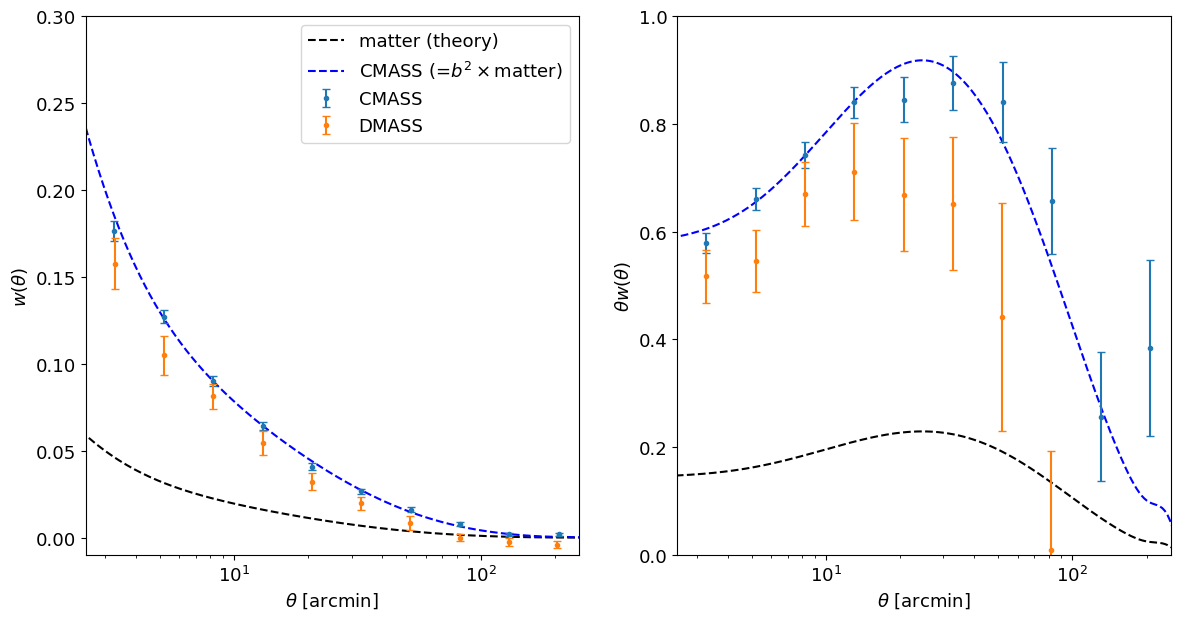

In [98]:
fig, (ax, ax2) = plt.subplots(1,2, figsize=(14,7))
#ax.semilogx(theta_cmass_theory, wtheta_cmass_theory, '--', color='blue', label='CMASS (theory)')
ax.semilogx(theta_matter_theory, wtheta_matter_theory, '--', color='black', label='matter (theory)')
ax.semilogx(theta_matter_theory, wtheta_cmass_theory, '--', color='blue', label='CMASS (=$b^2\\times$matter)')
ax.errorbar(theta_cmass, wtheta_cmass, yerr=err_wtheta_cmass, label='CMASS', color='tab:blue', capsize=3, fmt='.')
ax.errorbar(theta_dmass, wtheta_dmass, yerr=err_wtheta_dmass, label='DMASS', color='tab:orange', capsize=3, fmt='.')
ax.set_xlim(2.5, 250)
ax.set_ylim(-0.01, 0.3)
ax.set_xscale('log')
ax.set_xlabel(r'$\theta$ [arcmin]')
ax.set_ylabel(r'$w(\theta)$')
ax.legend()


ax2.semilogx(theta_cmass_theory, theta_cmass_theory*wtheta_cmass_theory, '--', color='blue', label='$w_{\\rm matter} (\\theta)$, theory')
ax2.semilogx(theta_matter_theory, theta_matter_theory*wtheta_matter_theory, '--', color='black', label='$w_{\\rm cmass} (\\theta) $, theory')
ax2.errorbar(theta_cmass, theta_cmass*wtheta_cmass, yerr=theta_cmass*err_wtheta_cmass, label='CMASS', color='tab:blue', capsize=3, fmt='.')
ax2.errorbar(theta_dmass, theta_dmass*wtheta_dmass, yerr=theta_dmass*err_wtheta_dmass, label='DMASS', color='tab:orange', capsize=3, fmt='.')

ax2.set_xlim(2.5, 250)
ax2.set_ylim(0.0, 1)

ax2.set_xscale('log')
ax2.set_xlabel(r'$\theta$ [arcmin]')
ax2.set_ylabel(r'$\theta w(\theta)$')



# Fitting the galaxy bias parameter

Use the least square method to find the best-fit galaxy bias parameter b for both CMASS and DMASS datasets. The model for the correlation function is given by:

To find the best-fit $b$, we compare the data to the model at many trial values of b and ask: which value makes the model curve fit the data most closely, accounting for the measurement errors (and their correlations, via the covariance matrix)?

The standard way to quantify how well a model fits is the chi-squared statistic:

$$ \chi^2 = ({ \rm data} - {\rm model})^T \cdot C^-1 \cdot ({\rm data} - {\rm model}) $$

where $C$ is the covariance matrix. A smaller chi^2 means a better fit. Least-squares fitting means scanning over b and picking the value that minimizes $\chi^2$, that's our best-fit bias.

Minimum point of $\Delta \chi^2$ is where the galaxy bias is the bestfit. 

In [84]:
def func_wtheta_galaxy(theta, b):
    from scipy.interpolate import interp1d 
    wtheta_matter_interpolation = interp1d(theta_matter_theory, wtheta_matter_theory, kind='linear', bounds_error=False, fill_value=0.0)
    return b**2 * wtheta_matter_interpolation(theta)

def delta_chisq(data, cov, theory): 
    diff = data - theory
    invcov = np.linalg.inv(cov)
    dchi2 = np.dot(np.dot(diff, invcov), diff.T)
    return dchi2

In [ ]:
# for CMASS 
# We are computing delta chi-squared values for a range of galaxy bias parameters (b) to find the best-fit value that minimizes the difference between the observed correlation function and the theoretical model.
bparams = np.linspace(1.5, 2.5, 1000)
dchisq_values_cmass = np.zeros(bparams.size) 
for i, b in enumerate(bparams):
    model = func_wtheta_galaxy(theta_cmass, b)
    dchi2 = delta_chisq(wtheta_cmass, cov_cmass, model)
    dchisq_values_cmass[i] = dchi2

# find the minimum point of the delta chi-squared values
argmin_idx = np.argmin(dchisq_values_cmass)
b_bestfit_cmass = bparams[argmin_idx]
print (f'bestfit CMASS galaxy bias: {b_bestfit_cmass:.3f}')

bestfit CMASS galaxy bias: 1.983


In [88]:

# Repeat for DMASS 
dchisq_values_dmass = np.zeros(bparams.size) 
for i, b in enumerate(bparams):
    model = func_wtheta_galaxy(theta_dmass, b)
    dchi2 = delta_chisq(wtheta_dmass, cov_dmass, model)
    dchisq_values_dmass[i] = dchi2

# find the minimum point of the delta chi-squared values
argmin_idx = np.argmin(dchisq_values_dmass)
b_bestfit_dmass = bparams[argmin_idx]
print (f'bestfit DMASS galaxy bias: {b_bestfit_dmass:.3f}')


bestfit DMASS galaxy bias: 1.881


Plot $\Delta \chi^2$ curves 

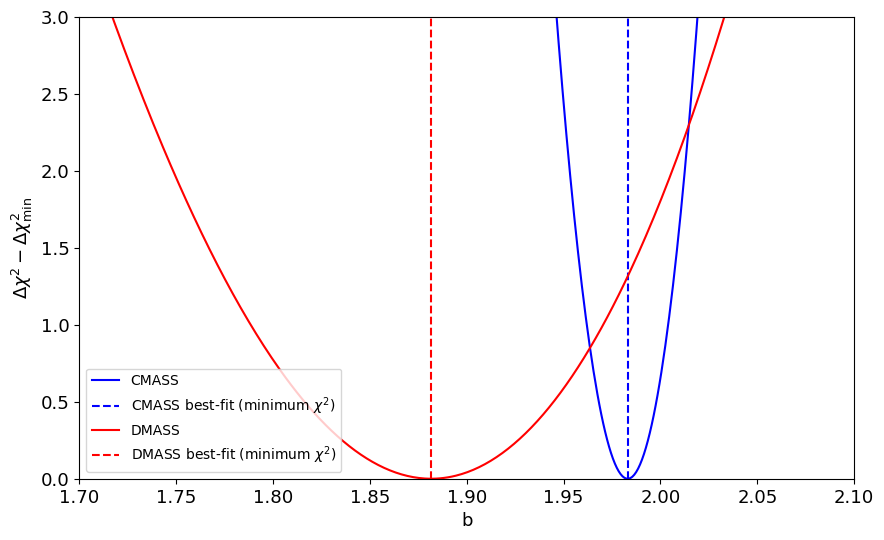

In [53]:
fig, ax = plt.subplots()
ax.plot(bparams, dchisq_values_cmass - dchisq_values_cmass.min(), color='blue', label='CMASS')
ax.axvline(x=b_bestfit_cmass, color='blue', linestyle='--', label='CMASS best-fit (minimum $\chi^2$)')
ax.plot(bparams, dchisq_values_dmass - dchisq_values_dmass.min(), color='red', label='DMASS')
ax.axvline(x=b_bestfit_dmass, color='red', linestyle='--', label='DMASS best-fit (minimum $\chi^2$)')
ax.set_xlabel('b')
ax.set_ylabel(r'$\Delta \chi^2 - \Delta \chi^2_{\rm min}$')
ax.set_ylim(0,3)
ax.set_xlim(1.7, 2.1)
ax.legend(fontsize=10, loc='lower left')

Let's find the 1-sigma confidence interval for the galaxy bias parameter b. The 1-sigma confidence interval corresponds to the range of $b$ values where the change in chi-squared ($\delta \chi^2$) is less than or equal to 1 from the minimum chi-squared value.

The best-fit $b$ is a single number, but we also want to know how well-constrained it is, i.e., its uncertainty. Near the minimum, $\chi^2$ rises as $b$ moves away from the best-fit value; the faster it rises, the more tightly constrained $b$ is.

The 1-sigma (68%) confidence interval is the range of b where delta $\chi^2 = \chi^2(b) - \chi^2_{\rm min} <= 1$. This comes from the fact that, for a single fit parameter, points where delta $\chi^2 = 1$ mark the boundary of the region containing 68% of the probability, the same 68% as plus/minus 1 sigma of a Gaussian. So instead of computing a formal probability distribution, we can just read off the width of the $\chi^2$ curve.

In [89]:
left_mask = bparams <= b_bestfit_cmass
right_mask = bparams >= b_bestfit_cmass

from scipy.interpolate import interp1d
f_left = interp1d(dchisq_values_cmass[left_mask]- dchisq_values_cmass.min(), bparams[left_mask])
f_right = interp1d(dchisq_values_cmass[right_mask]- dchisq_values_cmass.min(), bparams[right_mask])
b_lower_cmass = f_left(1.0)
b_upper_cmass = f_right(1.0)
sigma_minus = b_bestfit_cmass - b_lower_cmass
sigma_plus = b_upper_cmass - b_bestfit_cmass
print ('\nCMASS')
print (f'bestfit galaxy bias: {b_bestfit_cmass:.3f}')
print ( f'b = {b_bestfit_cmass:.3f} - {sigma_minus:.3f} + {sigma_plus:.3f}'  )
print (f'{b_lower_cmass:.3f} < b < {b_upper_cmass:.3f}')


CMASS
bestfit galaxy bias: 1.983
b = 1.983 - 0.021 + 0.020
1.962 < b < 2.004


In [90]:

# Repeat for DMASS 
left_mask = bparams <= b_bestfit_dmass
right_mask = bparams >= b_bestfit_dmass

from scipy.interpolate import interp1d
f_left = interp1d(dchisq_values_dmass[left_mask]- dchisq_values_dmass.min(), bparams[left_mask])
f_right = interp1d(dchisq_values_dmass[right_mask]- dchisq_values_dmass.min(), bparams[right_mask])
b_lower_dmass = f_left(1.0)
b_upper_dmass = f_right(1.0)
sigma_minus_dmass = b_bestfit_dmass - b_lower_dmass
sigma_plus_dmass = b_upper_dmass - b_bestfit_dmass

print ('\nDMASS')
print (f'bestfit galaxy bias: {b_bestfit_dmass:.3f}')
print ( f'b = {b_bestfit_dmass:.3f} - {sigma_minus_dmass:.3f} + {sigma_plus_dmass:.3f}'  )
print (f'{b_lower_dmass:.3f} < b < {b_upper_dmass:.3f}')


DMASS
bestfit galaxy bias: 1.881
b = 1.881 - 0.093 + 0.089
1.788 < b < 1.970


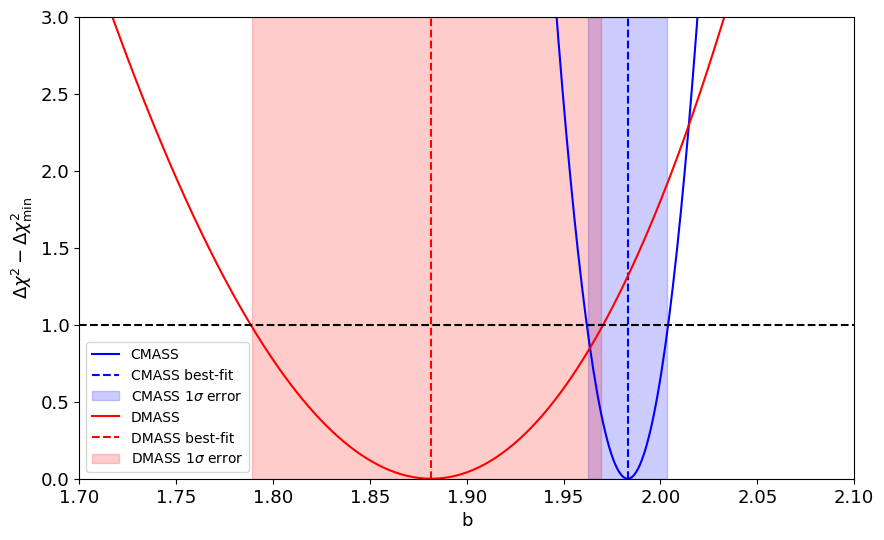

In [65]:
fig, ax = plt.subplots()
ax.plot(bparams, dchisq_values_cmass - dchisq_values_cmass.min(), color='blue', label='CMASS')
ax.axvline(x=b_bestfit_cmass, color='blue', linestyle='--', label='CMASS best-fit')
#ax.fill_between(bparams, dchisq_values_cmass - dchisq_values_cmass.min(), 1, where=(bparams >= b_lower) & (bparams <= b_upper), color='blue', alpha=0.2)
ax.fill_between(bparams, 0, 3, where=(bparams >= b_lower) & (bparams <= b_upper), color='blue', alpha=0.2, label='CMASS 1$\sigma$ error')
ax.plot(bparams, dchisq_values_dmass - dchisq_values_dmass.min(), color='red', label='DMASS')
ax.axvline(x=b_bestfit_dmass, color='red', linestyle='--', label='DMASS best-fit')
ax.axhline(y=1, color='black', linestyle='--')
#ax.errorbar(b_bestfit_dmass, 1, xerr=[[sigma_minus_dmass], [sigma_plus_dmass]], capsize=5, fmt='o', color='red', label='DMASS best-fit')
#ax.fill_between(bparams, dchisq_values_dmass - dchisq_values_dmass.min(), 1, where=(bparams >= b_lower_dmass) & (bparams <= b_upper_dmass), color='red', alpha=0.2)
ax.fill_between(bparams, 0,3, where=(bparams >= b_lower_dmass) & (bparams <= b_upper_dmass), color='red', alpha=0.2, label='DMASS 1$\sigma$ error')
ax.set_xlabel('b')
ax.set_ylabel(r'$\Delta \chi^2 - \Delta \chi^2_{\rm min}$')
ax.set_ylim(0,3)
ax.set_xlim(1.7, 2.1)

ax.legend()
ax.legend(fontsize=10, loc='lower left')

We did this manually above by scanning over b, but `scipy.optimize.curve_fit` does the same minimization automatically, and also returns the parameter covariance `pcov` directly. For a single parameter with a linear model like ours, the square root of pcov is the 1-sigma error, equivalent to the delta $\chi^2 = 1$ width we found by hand. This gives us a quick cross-check of the grid-search result above.

In [91]:
from scipy.optimize import curve_fit

In [ ]:
popt, pcov = curve_fit(func_wtheta_galaxy, theta_cmass, wtheta_cmass, sigma=cov_cmass, absolute_sigma=True)
bestfit = popt[0]
error = np.sqrt(pcov[0][0])

print ('bestfit galaxy bias: ', bestfit)
print ('error: ', error)
print ( f'b = {bestfit:.3f} ± {error:.3f}'  )
print (f'{bestfit - error:.3f} < b < {bestfit + error:.3f}')

bestfit galaxy bias:  1.9830959412683014
error:  0.020992844890903677
b = 1.983 ± 0.021
1.962 < b < 2.004


In [ ]:
# Repeat for DMASS 
popt, pcov = curve_fit(func_wtheta_galaxy, theta_dmass, wtheta_dmass, sigma=cov_dmass, absolute_sigma=True)
bestfit = popt[0]
error = np.sqrt(pcov[0][0])

print ('bestfit galaxy bias: ', bestfit)
print ('error: ', error)
print ( f'b = {bestfit:.3f} ± {error:.3f}'  )
print (f'{bestfit - error:.3f} < b < {bestfit + error:.3f}')

bestfit galaxy bias:  1.881674841492662
error:  0.0908696500810085
b = 1.882 ± 0.091
1.791 < b < 1.973


# Discussion

1. What is the bestfit galaxy bias parameter b for CMASS and your DMASS? How do they compare?

2. Look at the shape of the $\Delta \chi^2$ curves for CMASS and DMASS. Is one broader than the other? What does that tell you about how well each bias is constrained, and why might the two samples have different sized error bars?

3. Repeat this for the preliminary DMASS sample and compare this with yours. Which one is closer to CMASS? Do you think why one is better than the other?

5. If your DMASS variant has a higher or lower bias than CMASS, what would that suggest physically about the galaxies in your sample (e.g. typical halo mass, luminosity)?